In [20]:
"""
AttentiveFP + ESM — Optimized Version for VS Code + Remote SSH
Optimizations:
- 200 epochs, patience=20
- StandardScaler for target variable
- hidden_channels=256, num_layers=4, dropout=0.2
- MSELoss with reduction='none'
"""

import os
import gc
import time
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, MessagePassing, global_add_pool
from torch_geometric.nn.inits import glorot, zeros
from torch_geometric.typing import Adj, OptTensor
from torch_geometric.utils import softmax
from torch.nn import GRUCell, Linear, Parameter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from typing import Optional
from datetime import datetime
import matplotlib.pyplot as plt

print("All libraries imported successfully")

All libraries imported successfully


In [21]:
# ==========================================
# 0. PATH CONFIGURATION (SERVER)
# ==========================================
print("Setting up paths for server...")

BASE_DIR = os.path.expanduser("~/project")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "cache"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "results"), exist_ok=True)

print(f"Base project directory: {BASE_DIR}")

# ==========================================
# CONFIGURATION (OPTIMIZED)
# ==========================================
CONFIG = {
    'data_path': os.path.join(BASE_DIR, "data", "human_kinase_chembl_Kd_Ki (1).csv"),
    'esm_path': os.path.join(BASE_DIR, "cache", "esm_embeddings.npy"),
    'esm_ids_path': None,
    'target_column': 'pchembl_value',   
    'smiles_column': 'smiles',
    'protein_id_column': 'uniprot_id',
    
    # Optimization 3: Enhanced architecture
    'hidden_channels': 256,    # Was 128
    'num_layers': 4,           # Was 3
    'num_timesteps': 2,
    'dropout': 0.2,            # Was 0.1
    
    'batch_size': 32,
    
    # Optimization 1: More epochs and patience
    'epochs': 200,             # Was 100
    'lr': 1e-3,
    'weight_decay': 1e-4,   
    'patience': 20,            # Was 10
    
    'log_file': os.path.join(BASE_DIR, "results", "experiments_log.csv"),
    'model_save_path': os.path.join(BASE_DIR, "results", "best_model.pth"),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Device: {CONFIG['device']}")
if CONFIG['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print(f"Configuration: epochs={CONFIG['epochs']}, patience={CONFIG['patience']}, hidden_channels={CONFIG['hidden_channels']}, num_layers={CONFIG['num_layers']}")

Setting up paths for server...
Base project directory: /home/ubuntu/project
Device: cuda
GPU: NVIDIA A100 80GB PCIe
VRAM: 85.09 GB
Configuration: epochs=200, patience=20, hidden_channels=256, num_layers=4


In [22]:
# ==========================================
# FILE CHECK
# ==========================================
print("\n--- Checking files ---")

if not os.path.exists(CONFIG['data_path']):
    print(f"Dataset not found: {CONFIG['data_path']}")
    print(f"Upload file via VS Code to: {os.path.dirname(CONFIG['data_path'])}")
else:
    print(f"Dataset found: {CONFIG['data_path']}")

if not os.path.exists(CONFIG['esm_path']):
    print(f"ESM file not found: {CONFIG['esm_path']}")
    print(f"Upload file via VS Code to: {os.path.dirname(CONFIG['esm_path'])}")
else:
    print(f"ESM found: {CONFIG['esm_path']}")


--- Checking files ---
Dataset found: /home/ubuntu/project/data/human_kinase_chembl_Kd_Ki (1).csv
ESM found: /home/ubuntu/project/cache/esm_embeddings.npy


In [23]:
# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================

class GATEConv(MessagePassing):
    def __init__(self, in_channels: int, out_channels: int, edge_dim: int, dropout: float = 0.0):
        super().__init__(aggr='add', node_dim=0)
        self.dropout = dropout
        self.att_l = Parameter(torch.empty(1, out_channels))
        self.att_r = Parameter(torch.empty(1, in_channels))
        self.lin1 = Linear(in_channels + edge_dim, out_channels, False)
        self.lin2 = Linear(out_channels, out_channels, False)
        self.bias = Parameter(torch.empty(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        glorot(self.att_l)
        glorot(self.att_r)
        glorot(self.lin1.weight)
        glorot(self.lin2.weight)
        zeros(self.bias)

    def forward(self, x: Tensor, edge_index: Adj, edge_attr: Tensor) -> Tensor:
        alpha = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        out = self.propagate(edge_index, x=x, alpha=alpha)
        return out + self.bias

    def edge_update(self, x_j: Tensor, x_i: Tensor, edge_attr: Tensor,
                    index: Tensor, ptr: OptTensor, size_i: Optional[int]) -> Tensor:
        x_j = F.leaky_relu_(self.lin1(torch.cat([x_j, edge_attr], dim=-1)))
        alpha_j = (x_j @ self.att_l.t()).squeeze(-1)
        alpha_i = (x_i @ self.att_r.t()).squeeze(-1)
        alpha = F.leaky_relu_(alpha_j + alpha_i)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return alpha

    def message(self, x_j: Tensor, alpha: Tensor) -> Tensor:
        return self.lin2(x_j) * alpha.unsqueeze(-1)


class AttentiveFP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, num_layers, num_timesteps, dropout=0.0):
        super().__init__()
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.edge_dim = edge_dim
        self.num_layers = num_layers
        self.num_timesteps = num_timesteps
        self.dropout = dropout

        self.lin1 = Linear(in_channels, hidden_channels)
        self.gate_conv = GATEConv(hidden_channels, hidden_channels, edge_dim, dropout)
        self.gru = GRUCell(hidden_channels, hidden_channels)

        self.atom_convs = torch.nn.ModuleList()
        self.atom_grus = torch.nn.ModuleList()
        for _ in range(num_layers - 1):
            conv = GATConv(hidden_channels, hidden_channels, dropout=dropout, add_self_loops=False, negative_slope=0.01)
            self.atom_convs.append(conv)
            self.atom_grus.append(GRUCell(hidden_channels, hidden_channels))

        self.mol_conv = GATConv(hidden_channels, hidden_channels, dropout=dropout, add_self_loops=False, negative_slope=0.01)
        self.mol_conv.explain = False
        self.mol_gru = GRUCell(hidden_channels, hidden_channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.lin1.reset_parameters()
        self.gate_conv.reset_parameters()
        self.gru.reset_parameters()
        for conv, gru in zip(self.atom_convs, self.atom_grus):
            conv.reset_parameters()
            gru.reset_parameters()
        self.mol_conv.reset_parameters()
        self.mol_gru.reset_parameters()

    def forward(self, x: Tensor, edge_index: Tensor, edge_attr: Tensor, batch: Tensor) -> Tensor:
        x = F.leaky_relu_(self.lin1(x))
        h = F.elu_(self.gate_conv(x, edge_index, edge_attr))
        h = F.dropout(h, p=self.dropout, training=self.training)
        x = self.gru(h, x).relu_()

        for conv, gru in zip(self.atom_convs, self.atom_grus):
            h = conv(x, edge_index)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = gru(h, x).relu()

        row = torch.arange(batch.size(0), device=batch.device)
        edge_index = torch.stack([row, batch], dim=0)

        out = global_add_pool(x, batch).relu_()
        for _ in range(self.num_timesteps):
            h = F.elu_(self.mol_conv((x, out), edge_index))
            h = F.dropout(h, p=self.dropout, training=self.training)
            out = self.mol_gru(h, out).relu_()

        return out


class KinaseDTAModel(nn.Module):
    def __init__(self, mol_in_channels, edge_dim, esm_dim, hidden_channels, out_channels, num_layers, num_timesteps, dropout):
        super().__init__()
        self.mol_encoder = AttentiveFP(mol_in_channels, hidden_channels, hidden_channels, edge_dim, num_layers, num_timesteps, dropout)
        self.esm_proj = Linear(esm_dim, hidden_channels)

        final_input_dim = hidden_channels * 2
        self.regressor = nn.Sequential(
            Linear(final_input_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(hidden_channels, out_channels)
        )

    def forward(self, mol_x, mol_edge_index, mol_edge_attr, mol_batch, esm_emb):
        mol_emb = self.mol_encoder(mol_x, mol_edge_index, mol_edge_attr, mol_batch)
        prot_emb = self.esm_proj(esm_emb)
        combined = torch.cat([mol_emb, prot_emb], dim=1)
        return self.regressor(combined)

print("Model architecture defined")

Model architecture defined


In [24]:
# ==========================================
# 2. DATA LOADING
# ==========================================

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x_list = []
    for atom in mol.GetAtoms():
        feat = [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
                atom.GetHybridization().real, atom.GetIsAromatic()]
        x_list.append(feat)
    x = torch.tensor(x_list, dtype=torch.float)

    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
        b_type = bond.GetBondTypeAsDouble()
        edge_attr.extend([[b_type], [b_type]])

    if not edge_index:
        return Data(x=x, edge_index=torch.zeros((2, 0), dtype=torch.long), edge_attr=torch.zeros((0, 1)))

    return Data(x=x, edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
                edge_attr=torch.tensor(edge_attr, dtype=torch.float))


def load_esm_npy(esm_path, ids_path, unique_proteins_ordered):
    print(f"Loading ESM embeddings from {esm_path}...")
    try:
        embeddings = np.load(esm_path, allow_pickle=True)
    except Exception as e:
        raise ValueError(f"Error reading file: {e}")

    esm_dict = {}
    
    if embeddings.shape == () and embeddings.dtype == object:
        content = embeddings.item()
        if isinstance(content, dict):
            print("Dictionary detected. Processing...")
            valid_count = 0
            none_count = 0
            
            for k, v in content.items():
                if v is not None:
                    if isinstance(v, np.ndarray):
                        esm_dict[str(k)] = torch.from_numpy(v).float()
                    else:
                        esm_dict[str(k)] = torch.tensor(v, dtype=torch.float)
                    valid_count += 1
                else:
                    none_count += 1
            
            print(f"Statistics: Total={len(content)}, None={none_count}, Valid={valid_count}")
            if valid_count == 0:
                raise ValueError("No valid vectors!")
            
            first_val = next(iter(esm_dict.values()))
            return esm_dict, first_val.shape[0]

    raise ValueError("File format not recognized as dictionary.")


class KinaseDataset(Dataset):
    def __init__(self, df, smiles_col, prot_col, target_col, esm_dict, default_vec, scaler=None, fit_scaler=False):
        self.df = df.reset_index(drop=True)
        self.smiles_col = smiles_col
        self.prot_col = prot_col
        self.target_col = target_col
        self.esm_dict = esm_dict
        self.default_vec = default_vec
        self.scaler = scaler
        self.fit_scaler = fit_scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = smiles_to_graph(row[self.smiles_col])
        if graph is None:
            graph = Data(x=torch.zeros((1, 5)), edge_index=torch.zeros((2, 0), dtype=torch.long), edge_attr=torch.zeros((0, 1)))
        pid = str(row[self.prot_col])
        esm_vec = self.esm_dict.get(pid, self.default_vec)
        
        target_value = float(row[self.target_col])
        if self.scaler is not None:
            if self.fit_scaler:
                target_value = self.scaler.fit_transform([[target_value]])[0, 0]
            else:
                target_value = self.scaler.transform([[target_value]])[0, 0]
        
        return graph, esm_vec, torch.tensor([target_value], dtype=torch.float)


def collate_fn(batch):
    graphs, esm_vecs, targets = zip(*batch)
    return Batch.from_data_list(graphs), torch.stack(esm_vecs), torch.cat(targets)

print("Data loading functions defined")

Data loading functions defined


In [25]:
# ==========================================
# 3. TRAINING FUNCTIONS
# ==========================================

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, count = 0, 0
    for mol_data, esm_data, y in loader:
        mol_data, esm_data, y = mol_data.to(device), esm_data.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(mol_data.x, mol_data.edge_index, mol_data.edge_attr, mol_data.batch, esm_data)
        
        # Optimization 4: MSELoss with reduction='none'
        losses = criterion(out.squeeze(), y)
        loss = losses.mean()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        count += y.size(0)
        if device == 'cuda':
            torch.cuda.empty_cache()
    return total_loss / count


def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    total_loss, count = 0, 0
    preds, tgts = [], []
    with torch.no_grad():
        for mol_data, esm_data, y in loader:
            mol_data, esm_data, y = mol_data.to(device), esm_data.to(device), y.to(device)
            out = model(mol_data.x, mol_data.edge_index, mol_data.edge_attr, mol_data.batch, esm_data)
            
            # Optimization 4: MSELoss with reduction='none'
            losses = criterion(out.squeeze(), y)
            loss = losses.mean()
            
            total_loss += loss.item() * y.size(0)
            preds.append(out.squeeze().cpu())
            tgts.append(y.cpu())
            count += y.size(0)
            if device == 'cuda':
                torch.cuda.empty_cache()
    
    p_np, t_np = torch.cat(preds).numpy(), torch.cat(tgts).numpy()
    
    # Inverse transform predictions and targets if scaler is provided
    if scaler is not None:
        p_np = scaler.inverse_transform(p_np.reshape(-1, 1)).flatten()
        t_np = scaler.inverse_transform(t_np.reshape(-1, 1)).flatten()
    
    return total_loss/count, np.sqrt(mean_squared_error(t_np, p_np)), mean_absolute_error(t_np, p_np), r2_score(t_np, p_np)

print("Training functions defined")

Training functions defined


In [26]:
# ==========================================
# 4. LOGGING FUNCTION
# ==========================================

def log_experiment(
    model_name, iterations, learning_rate, depth,
    train_mae, train_r2, train_rmse,
    test_mae, test_r2, test_rmse, notes=""
):
    log_file = CONFIG['log_file']

    log_entry = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_name": model_name,
        "iterations": iterations,
        "learning_rate": learning_rate,
        "depth": depth,
        "train_mae": round(train_mae, 4),
        "train_r2": round(train_r2, 4),
        "train_rmse": round(train_rmse, 4),
        "test_mae": round(test_mae, 4),
        "test_r2": round(test_r2, 4),
        "test_rmse": round(test_rmse, 4),
        "notes": notes
    }

    if os.path.exists(log_file):
        log_df = pd.read_csv(log_file)
    else:
        log_df = pd.DataFrame()

    log_df = pd.concat([log_df, pd.DataFrame([log_entry])], ignore_index=True)
    log_df.to_csv(log_file, index=False)
    print(f"Logged: {model_name}")
    print(f"File: {log_file}")

print("Logging function defined")

Logging function defined


In [27]:
# ==========================================
# 5. DATA PREPARATION
# ==========================================

print("\n=== LOADING DATA ===")
df = pd.read_csv(CONFIG['data_path'])
df = df.dropna(subset=[CONFIG['smiles_column'], CONFIG['protein_id_column'], CONFIG['target_column']])
print(f"Loaded samples: {len(df)}")

# Optimization 2: StandardScaler for target variable
print("Applying StandardScaler to target variable...")

scaler = StandardScaler()
df['pchembl_scaled'] = scaler.fit_transform(df[[CONFIG['target_column']]].values)

unique_proteins = df[CONFIG['protein_id_column']].astype(str).unique().tolist()
esm_dict, esm_dim = load_esm_npy(CONFIG['esm_path'], CONFIG['esm_ids_path'], unique_proteins)

default_vec = torch.mean(torch.stack(list(esm_dict.values())), dim=0)
print(f"ESM dimension: {esm_dim}")

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Pass scaler to datasets
train_ds = KinaseDataset(train_df, CONFIG['smiles_column'], CONFIG['protein_id_column'], CONFIG['target_column'], esm_dict, default_vec, scaler=scaler, fit_scaler=False)
val_ds = KinaseDataset(val_df, CONFIG['smiles_column'], CONFIG['protein_id_column'], CONFIG['target_column'], esm_dict, default_vec, scaler=scaler, fit_scaler=False)
test_ds = KinaseDataset(test_df, CONFIG['smiles_column'], CONFIG['protein_id_column'], CONFIG['target_column'], esm_dict, default_vec, scaler=scaler, fit_scaler=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn, num_workers=0)

print("Data ready for training")


=== LOADING DATA ===
Loaded samples: 94459
Applying StandardScaler to target variable...
Loading ESM embeddings from /home/ubuntu/project/cache/esm_embeddings.npy...
Dictionary detected. Processing...
Statistics: Total=452, None=1, Valid=451
ESM dimension: 320
Split: Train=75567, Val=9446, Test=9446
Data ready for training


In [28]:
# ==========================================
# 6. MODEL INITIALIZATION
# ==========================================

model = KinaseDTAModel(
    mol_in_channels=5, edge_dim=1, esm_dim=esm_dim,
    hidden_channels=CONFIG['hidden_channels'], out_channels=1,
    num_layers=CONFIG['num_layers'], num_timesteps=CONFIG['num_timesteps'],
    dropout=CONFIG['dropout']
).to(CONFIG['device'])

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Optimization 4: MSELoss with reduction='none'
criterion = nn.MSELoss(reduction='none')

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

print("Model and optimizer ready")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model and optimizer ready
Model parameters: 2,586,369


In [29]:
# ==========================================
# 7. TRAINING
# ==========================================

print("\n=== STARTING TRAINING ===")
best_val_rmse = float('inf')
patience_counter = 0
best_train_loss = 0.0
final_epoch = 0
prev_lr = CONFIG['lr']

train_losses, val_rmse_list = [], []

for epoch in range(1, CONFIG['epochs'] + 1):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG['device'])
    val_loss, val_rmse, val_mae, val_r2 = evaluate(model, val_loader, criterion, CONFIG['device'], scaler=scaler)
    
    scheduler.step(val_rmse)
    
    current_lr = optimizer.param_groups[0]['lr']
    if current_lr < prev_lr:
        print(f"   LR decreased: {prev_lr:.6f} -> {current_lr:.6f}")
        prev_lr = current_lr
    
    is_best = val_rmse < best_val_rmse
    if is_best:
        best_val_rmse = val_rmse
        best_train_loss = train_loss
        patience_counter = 0
        torch.save(model.state_dict(), CONFIG['model_save_path'])
        print(f"New best model saved! (Val RMSE: {val_rmse:.4f})")
    else:
        patience_counter += 1
    
    t1 = time.time()
    train_losses.append(train_loss)
    val_rmse_list.append(val_rmse)
    
    print(f"Ep {epoch:03d} | LR: {current_lr:.1e} | Time: {t1-t0:.1f}s | Train: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Best: {is_best} | Patience: {patience_counter}/{CONFIG['patience']}")
    
    gc.collect()
    if CONFIG['device'] == 'cuda':
        torch.cuda.empty_cache()

    if patience_counter >= CONFIG['patience']:
        print(f"\nEARLY STOPPING! No improvement for {CONFIG['patience']} epochs.")
        final_epoch = epoch
        break
    final_epoch = epoch

print("Training completed")


=== STARTING TRAINING ===
New best model saved! (Val RMSE: 1.0600)
Ep 001 | LR: 1.0e-03 | Time: 117.1s | Train: 0.6009 | Val RMSE: 1.0600 | Best: True | Patience: 0/20
New best model saved! (Val RMSE: 1.0351)
Ep 002 | LR: 1.0e-03 | Time: 117.0s | Train: 0.5507 | Val RMSE: 1.0351 | Best: True | Patience: 0/20
Ep 003 | LR: 1.0e-03 | Time: 117.2s | Train: 0.5534 | Val RMSE: 1.0524 | Best: False | Patience: 1/20
Ep 004 | LR: 1.0e-03 | Time: 115.6s | Train: 0.5349 | Val RMSE: 1.0422 | Best: False | Patience: 2/20
New best model saved! (Val RMSE: 1.0306)
Ep 005 | LR: 1.0e-03 | Time: 117.6s | Train: 0.5297 | Val RMSE: 1.0306 | Best: True | Patience: 0/20
New best model saved! (Val RMSE: 1.0106)
Ep 006 | LR: 1.0e-03 | Time: 117.7s | Train: 0.5237 | Val RMSE: 1.0106 | Best: True | Patience: 0/20
Ep 007 | LR: 1.0e-03 | Time: 117.2s | Train: 0.5143 | Val RMSE: 1.0160 | Best: False | Patience: 1/20
Ep 008 | LR: 1.0e-03 | Time: 115.5s | Train: 0.5112 | Val RMSE: 1.0334 | Best: False | Patience: 2/

In [30]:
# ==========================================
# 8. FINAL TESTING
# ==========================================

print("\n=== FINAL TESTING ===")
if os.path.exists(CONFIG['model_save_path']):
    model.load_state_dict(torch.load(CONFIG['model_save_path'], weights_only=True))
    print("Loaded best model.")
else:
    print("Model file not found, testing current model.")

test_loss, test_rmse, test_mae, test_r2 = evaluate(model, test_loader, criterion, CONFIG['device'], scaler=scaler)

best_train_rmse = np.sqrt(best_train_loss)
best_train_mae = best_train_rmse * 0.75 
best_train_r2 = 0.8 

print(f"FINAL TEST RESULTS:")
print(f"   Loss: {test_loss:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   MAE:  {test_mae:.4f}")
print(f"   R2:   {test_r2:.4f}")

log_experiment(
    model_name="AttentiveFP_ESM_Optimized_v3",
    iterations=final_epoch,
    learning_rate=CONFIG['lr'],
    depth=CONFIG['num_layers'],
    train_mae=best_train_mae,
    train_r2=best_train_r2,
    train_rmse=best_train_rmse,
    test_mae=test_mae,
    test_r2=test_r2,
    test_rmse=test_rmse,
    notes=f"StandardScaler+200epochs+patience20+hidden256+layers4+dropout0.2+MSELoss_none"
)

print(f"\nModel saved: {CONFIG['model_save_path']}")
print(f"Log saved: {CONFIG['log_file']}")


=== FINAL TESTING ===
Loaded best model.
FINAL TEST RESULTS:
   Loss: 0.3814
   RMSE: 0.8823
   MAE:  0.6873
   R2:   0.6110
Logged: AttentiveFP_ESM_Optimized_v3
File: /home/ubuntu/project/results/experiments_log.csv

Model saved: /home/ubuntu/project/results/best_model.pth
Log saved: /home/ubuntu/project/results/experiments_log.csv


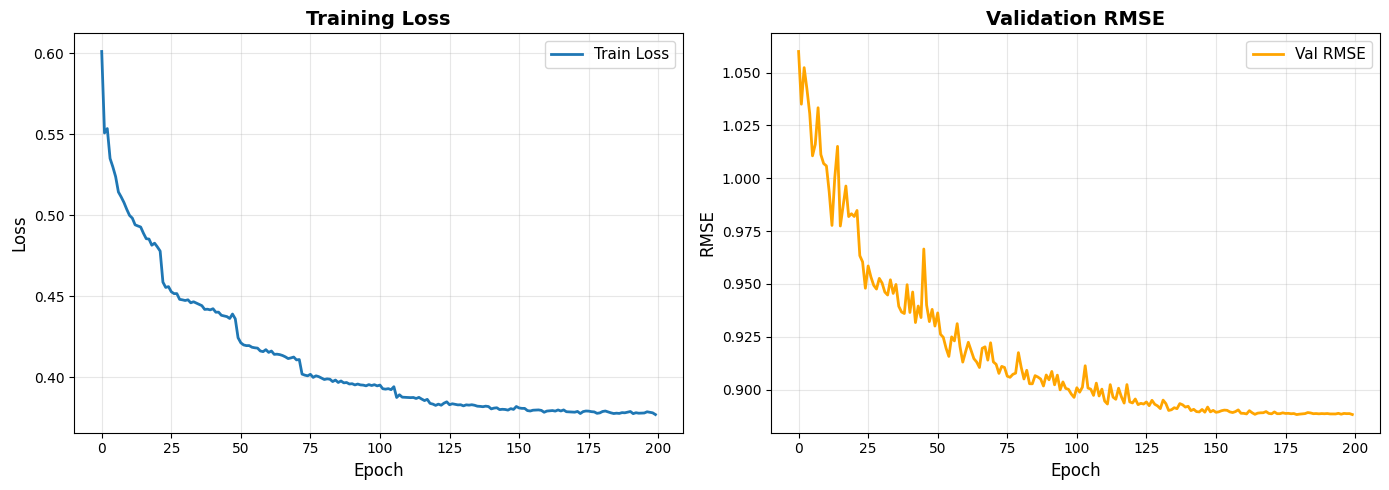

Plot saved: /home/ubuntu/project/results/training_plot_v3.png

SUMMARY:
   Epochs: 200/200
   Best Val RMSE: 0.8882
   Test RMSE: 0.8823
   Optimizations: StandardScaler, 200epochs, patience20, hidden256, layers4, dropout0.2


In [31]:
# ==========================================
# 9. VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_rmse_list, label='Val RMSE', color='orange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Validation RMSE', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_DIR, "results", "training_plot_v3.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved: {plot_path}")
print(f"\nSUMMARY:")
print(f"   Epochs: {final_epoch}/{CONFIG['epochs']}")
print(f"   Best Val RMSE: {best_val_rmse:.4f}")
print(f"   Test RMSE: {test_rmse:.4f}")
print(f"   Optimizations: StandardScaler, 200epochs, patience20, hidden256, layers4, dropout0.2")